<a href="https://colab.research.google.com/github/jhlopesalves/data-science-notebooks/blob/main/Python/machine_learning/intro_to_machine_learning/intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

## Module 0, Phase 1: The Statistical Bedrock

#### Descriptive vs. Inferential Statistics

At the highest level, statistics is a discipline for handling uncertainty. It provides a formal framework for describing information and for using that information to make educated guesses. These two purposes create the field's two great branches.

**1. Descriptive Statistics: What We Know**

Descriptive statistics is the process of summarising and describing the data you have. It makes no claims about any data you *do not* have. It is the act of taking a large, unwieldy set of numbers and distilling it into a few representative figures.

* **Goal:** To describe a *sample*.
* **Question:** "What does my *current data* look like?"
* **Tools:** Measures of central tendency (mean, median, mode) and measures of dispersion (variance, standard deviation, range, interquartile range).

Let's use a simple dataset for our calculations. Imagine we have a sample of 5 students and their exam scores. This sample is our entire dataset.

$X = \{80, 85, 90, 90, 100\}$

Our sample size, $n$, is 5.

**The Math of Description (Reading the "Greek")**

Let's look at the two most important descriptive formulas.

**A. The Sample Mean ($\bar{x}$)**

The mean, or average, is the most common measure of central tendency. The formula for the **sample mean**, denoted $\bar{x}$ (read "x-bar"), is:

$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

Let's break this "Greek" down, piece by piece, as you requested:
* $\bar{x}$: This is the *symbol* for the sample mean.
* $n$: This is the *number of observations* in our sample. Here, $n=5$.
* $x_i$: This represents a *single observation* in our dataset. $x_1$ is 80, $x_2$ is 85, and so on.
* $\sum_{i=1}^{n}$: This is the **Summation** symbol. It is just a "for loop." It means "starting with the first item ($i=1$), go up to the last item ($n$), and add them all together."

So, $\sum_{i=1}^{n} x_i$ is just $x_1 + x_2 + x_3 + x_4 + x_5$.
For our data: $80 + 85 + 90 + 90 + 100 = 445$.

The $\frac{1}{n}$ part simply means "divide by $n$."
So, $\bar{x} = \frac{1}{5} \times 445 = 89$.

The descriptive statistic for the centre of our data is 89. This is a fact *about our sample*.

**B. The Sample Variance ($s^2$)**

Variance is the most common measure of dispersion, or "spread." It answers, "How far, on average, are my data points from the mean?" The formula for the **sample variance**, $s^2$, is:

$$
s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2
$$

This formula is beautiful, and every piece of it is there for a critical reason.
* $(x_i - \bar{x})$: This is the **deviation** (or *residual*) for a single point. It is how far that point is from the mean.
    * $(80 - 89) = -9$
    * $(85 - 89) = -4$
    * $(90 - 89) = 1$
    * $(90 - 89) = 1$
    * $(100 - 89) = 11$
* $(...)^2$: We **square** the deviations. Why?
    1.  It makes all deviations positive. Notice our deviations sum to zero ($-9 - 4 + 1 + 1 + 11 = 0$), which is a mathematical property of the mean. Squaring them prevents them from cancelling each other out.
    2.  This is a *critical* point for machine learning: it *heavily penalises* large errors. The point at 100 has a deviation of 11, so its squared contribution is 121. The point at 85 has a deviation of -4, so its squared contribution is only 16. This is the exact same logic used in the **Mean Squared Error (MSE)** cost function.
* $\sum(...)^2$: The "sum of squares." We sum those squared deviations.
    * $(-9)^2 + (-4)^2 + (1)^2 + (1)^2 + (11)^2 = 81 + 16 + 1 + 1 + 121 = 220$.
* $\frac{1}{n-1}$: This is the "divide by" part. And it is the most subtle, beautiful piece of this formula. Why not $n$?
    * This is known as **Bessel's correction**. The short, conceptual reason is that our sample mean, $\bar{x}$, is itself an *estimate* of the "true" population mean, $\mu$. Because $\bar{x}$ is calculated *from our sample*, it is already "closer" to our sample points than the true $\mu$ would be.
    * This means our sum of squares, $\sum (x_i - \bar{x})^2$, is slightly *smaller* than the "true" sum of squares, $\sum (x_i - \mu)^2$.
    * To correct for this, we divide by a slightly smaller number, $n-1$, which inflates our final variance just a tiny bit. This inflation makes $s^2$ a more accurate, *unbiased* estimate of the population's true variance.
    * This $n-1$ is your first glimpse of the bridge between descriptive and inferential statistics.

Let's finish the calculation:
$s^2 = \frac{1}{5-1} \times 220 = \frac{1}{4} \times 220 = 55$.

The descriptive statistics for our sample are: mean = 89 and variance = 55. We can also take the square root of the variance to get the **sample standard deviation**, $s = \sqrt{55} \approx 7.42$.




**3. The Bridge to Machine Learning**

This distinction is the single most important concept for understanding what machine learning is.

When we build a supervised model, our **training dataset** is a *sample*. It is a small, limited subset of all possible data in the universe.

The "true," perfect, underlying function that maps our inputs $X$ to our outputs $Y$, which we call $f(X)$, is the *population parameter*. It is the "truth" we can never perfectly know.

Our *trained model*, $\hat{f}(X)$ (read "f-hat"), is a *statistic*. It is an *inference* we have built *from our sample only*.

* **Descriptive:** When we calculate the `model.score()` on our *training data*, we are getting a descriptive statistic (e.g., "On the data I have, my model got 99% accuracy").
* **Inferential:** When we calculate the `model.score()` on our *test data*, we are performing an act of inference. We are estimating how well our model, $\hat{f}(X)$, will *generalise* to the "real world" (the population) it has never seen.

This is why we have concepts like **overfitting**. Overfitting occurs when our model learns the *noise and quirks of our sample* ($\bar{x}$) so well that it is no longer a good representation of the *true underlying pattern* ($\mu$).

Everything we do from here—hypothesis testing, p-values, and even building complex neural networks—is just a more and more sophisticated version of this core problem: using a limited sample to make a useful guess about the world at large.

### Module 0, Phase 1 (Continued): Probability Distributions

Before we can make an "educated guess" (an inference), we need a formal way to describe the *likelihood* of all the possible outcomes. That is what a probability distribution does.

* A **Discrete Distribution** handles outcomes you can *count* (e.g., a coin flip has two outcomes: {Heads, Tails}; a die roll has six: {1, 2, 3, 4, 5, 6}).
* A **Continuous Distribution** handles outcomes you must *measure* (e.g., the height of a student, the temperature of a room, the price of a stock). The number of possible outcomes is infinite.

The most important continuous distribution in all of statistics—and the default model for "noise" or "error" in machine learning—is the **Normal Distribution**, also called the **Gaussian Distribution** or the "bell curve."

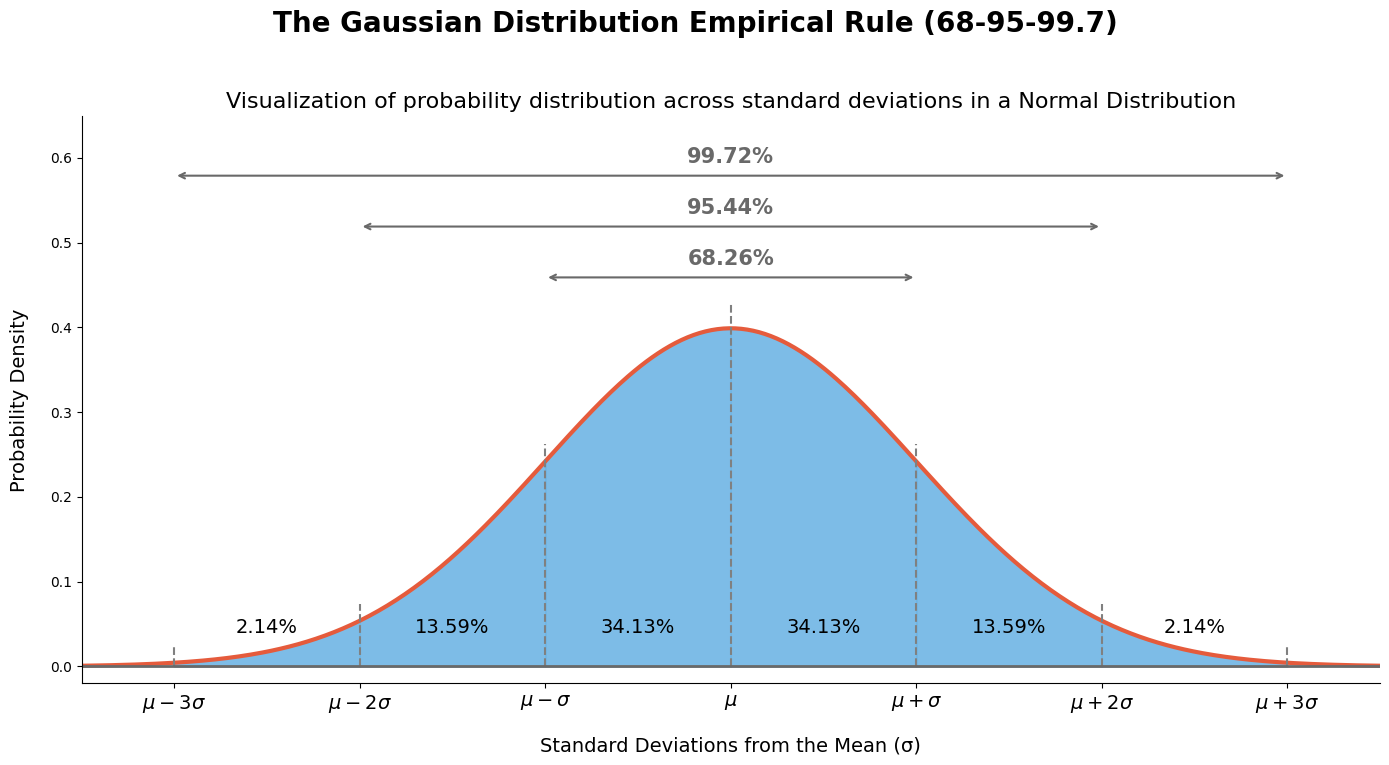

In [ ]:
from scipy.stats import norm

# 1. Set up the parameters for the normal distribution
mu, sigma = 0, 1
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
y = norm.pdf(x, mu, sigma)
peak_height = norm.pdf(
	mu, mu, sigma
)  # Define this early for use in capping the line height


# 2. Create the plot
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle(
	"The Gaussian Distribution Empirical Rule (68-95-99.7)",
	fontsize=20,
	fontweight="bold",
)
ax.set_title(
	"Visualization of probability distribution across standard deviations in a Normal Distribution",
	fontsize=16,
)

# Plot the main curve
ax.plot(x, y, color="#E55B3C", linewidth=3)

# 3. Shade the areas under the curve
std_devs = [-3, -2, -1, 0, 1, 2]
for sd in std_devs:
	x_fill = np.linspace(mu + sd * sigma, mu + (sd + 1) * sigma, 100)
	y_fill = norm.pdf(x_fill, mu, sigma)
	ax.fill_between(x_fill, y_fill, color="#6FB5E5", alpha=0.9)

# 4. Add vertical lines and customize x-axis ticks
tick_positions = [mu + i * sigma for i in range(-3, 4)]
tick_labels = [
	r"$\mu-3\sigma$",
	r"$\mu-2\sigma$",
	r"$\mu-\sigma$",
	r"$\mu$",
	r"$\mu+\sigma$",
	r"$\mu+2\sigma$",
	r"$\mu+3\sigma$",
]

# Using ax.vlines for precise control over the line heights in data coordinates.
for pos in tick_positions:
	y_max_at_pos = norm.pdf(pos, mu, sigma)

	# Set the end point of the line to be slightly above the curve by an absolute amount.
	y_end = y_max_at_pos + 0.02

	# For the center line, we apply a hard cap to its height to ensure it
	# does not overlap with the text annotations at the top.
	if pos == mu:
		# The first text annotation is at peak_height + 0.07, so this cap is safe.
		y_end = peak_height + 0.03

	ax.vlines(x=pos, ymin=0, ymax=y_end, color="gray", linestyle="--")


ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=14)
ax.set_xlabel("Standard Deviations from the Mean (σ)", fontsize=14, labelpad=15)

# 5. Add percentage annotations
annotations = {
	-2.5: "2.14%",
	-1.5: "13.59%",
	-0.5: "34.13%",
	0.5: "34.13%",
	1.5: "13.59%",
	2.5: "2.14%",
}
for pos, label in annotations.items():
	ax.text(mu + pos * sigma, 0.04, label, ha="center", fontsize=14)

# Cumulative percentages at the top
arrow_y_positions = [peak_height + 0.06, peak_height + 0.12, peak_height + 0.18]
arrow_text_positions = [y + 0.01 for y in arrow_y_positions]
cumulative_data = [(1, "68.26%"), (2, "95.44%"), (3, "99.72%")]
for i, (sd_range, text) in enumerate(cumulative_data):
	ax.annotate(
		"",
		xy=(mu - sd_range * sigma, arrow_y_positions[i]),
		xytext=(mu + sd_range * sigma, arrow_y_positions[i]),
		arrowprops=dict(arrowstyle="<->", color="dimgray", lw=1.5),
	)
	ax.text(
		mu,
		arrow_text_positions[i],
		text,
		ha="center",
		va="bottom",
		fontsize=15,
		fontweight="bold",
		color="dimgray",
	)

# 6. Final styling touches
ax.set_ylabel("Probability Density", fontsize=14, labelpad=15)
sns.despine(left=False, top=True, right=True, bottom=False)
ax.axhline(0, color="dimgray", linewidth=2)
ax.set_xlim(mu - 3.5 * sigma, mu + 3.5 * sigma)
ax.set_ylim(bottom=-0.02, top=peak_height + 0.25)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### The Math of the Normal Distribution (Reading the "Greek")

This is one of the most famous and intimidating formulas in all of mathematics. It is the **Probability Density Function (PDF)** for a normal distribution.

$$
f(x | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}
$$

Let's break this down. Do not be intimidated by it. You will almost never have to *calculate* this formula by hand. Our goal is to understand what its *components* tell us, so we can make better decisions with our code.

This formula, $f(x)$, gives you the *height* of the curve at any given point $x$.

**The Two Most Important Parts: The Parameters**

The entire shape of *any* normal distribution is defined by just two parameters, which we have already met:

1.  **$\mu$ (Mu): The Population Mean.**
    * This parameter controls the **location** of the curve.
    * It is the $x$-value at the very center, the peak of the bell.
    * If you change $\mu$, the entire curve slides left or right on the graph.

2.  **$\sigma$ (Sigma): The Population Standard Deviation.**
    * This parameter controls the **scale** or "spread" of the curve.
    * A small $\sigma$ means the data is tightly clustered around the mean (a tall, skinny spike).
    * A large $\sigma$ means the data is widely spread out (a short, fat curve).
    * $\sigma^2$ is, of course, the variance.

**The "Greek" We Can Ignore (The Normalizing Constant)**

What about all the other scary parts?
$$
\frac{1}{\sqrt{2\pi\sigma^2}} \quad \text{and} \quad e^{-\frac{...}{2\sigma^2}}
$$
* $e \approx 2.718$ (Euler's number)
* $\pi \approx 3.141$ (Pi)

These pieces are just a complex **normalizing constant**. Their *only* job is to ensure that the total **Area Under the Curve (AUC)** is *exactly 1*.

Why 1? Because in probability, 1 means 100%. This formula ensures that the probability of *all possible outcomes* (the entire area) sums to 100%.

The $e^{-...}$ part is what gives the curve its "bell" shape. The $(x - \mu)^2$ part is what makes it symmetric. Notice that a point at $x = \mu + 2$ and a point at $x = \mu - 2$ will give the *same* value for $(x - \mu)^2$, which is why the curve has perfect mirror symmetry around the mean $\mu$.

**How to Use This Math: The Empirical Rule (68-95-99.7)**

Here is the practical, usable payoff. Because the shape of the normal distribution is mathematically fixed, we *always* know what percentage of the data lies within a certain number of standard deviations ($\sigma$) from the mean ($\mu$).

This is the **Empirical Rule**.

* **$68\%$** of all data points fall within **1 standard deviation** of the mean.
    * (Between $\mu - 1\sigma$ and $\mu + 1\sigma$)
* **$95\%$** of all data points fall within **2 standard deviations** of the mean.
    * (Between $\mu - 2\sigma$ and $\mu + 2\sigma$)
* **$99.7\%$** of all data points fall within **3 standard deviations** of the mean.
    * (Between $\mu - 3\sigma$ and $\mu + 3\sigma$)

**Let's Apply This (Manual Calculation)**

Let's return to our student scores, $X = \{80, 85, 90, 90, 100\}$.

We *calculated* a sample mean $\bar{x} = 89$ and a sample standard deviation $s \approx 7.42$.

Now, let's *assume* that the scores for the *entire population* of students at this university are perfectly normally distributed with a true population mean **$\mu = 89$** and a true population standard deviation **$\sigma = 7.42$**.

(This is the *act of inference*—we are using our sample statistics as our "best guess" for the population parameters).

With this assumption, what can we say about the *entire university*?

1.  **68% of all students** should have scores between:
    * $\mu - 1\sigma$ and $\mu + 1\sigma$
    * $89 - 7.42$ and $89 + 7.42$
    * **Between 81.58 and 96.42**

2.  **95% of all students** should have scores between:
    * $\mu - 2\sigma$ and $\mu + 2\sigma$
    * $89 - (2 \times 7.42)$ and $89 + (2 \times 7.42)$
    * $89 - 14.84$ and $89 + 14.84$
    * **Between 74.16 and 103.84**

3.  **99.7% of all students** (i.e., almost everyone) should have scores between:
    * $\mu - 3\sigma$ and $\mu + 3\sigma$
    * $89 - (3 \times 7.42)$ and $89 + (3 \times 7.42)$
    * $89 - 22.26$ and $89 + 22.26$
    * **Between 66.74 and 111.26**

This rule gives us a powerful new ability. We can now identify **outliers**. If a student scored a 65, we could say that they are more than 3 standard deviations from the mean, an event that should happen (by our model) less than 0.3% of the time. It is a "statistically rare" event.

**The Bridge to Machine Learning**

Why did we just do this?

1.  **The "Error" Term ($\epsilon$):** In our foundational model, $Y = f(X) + \epsilon$, we almost always *assume* that the "irreducible error" term, $\epsilon$, is **normally distributed with a mean of 0**.
    * This is called the "Normal Error Assumption."
    * This assumption is the *mathematical justification* for using **Mean Squared Error (MSE)** as our cost function. The math that justifies using MSE as a "good" cost function is the same math that generates this bell curve.

2.  **A "Good" Model:** When we build a model, we often check the *residuals* (the $y_i - \hat{y}_i$ errors). If our model is "good" and has captured the true underlying pattern $f(X)$, then the residuals (the leftover $\epsilon$) should look like they are randomly sampled from a Normal(0, $\sigma^2$) distribution. If they *don't* (e.g., if they are all positive for a certain range of $X$), our model is biased.

### Module 0, Phase 1 (Continued): The z-score

We just saw that the Empirical Rule (68-95-99.7) tells us the *percentage* of data within 1, 2, or 3 standard deviations of the mean *for a normal distribution*. That is useful, but we often want to know something more specific: "How many standard deviations away *is this particular data point*?"

The **z-score** answers exactly that question.

* **Definition:** A z-score measures how many standard deviations a specific data point ($x$) is away from the mean ($\mu$).
* **Sign:** A positive z-score means the point is *above* the mean. A negative z-score means the point is *below* the mean. A z-score of 0 means the point *is* the mean.

#### The Math of the z-score (Reading the "Greek")

The formula for the z-score is beautifully simple:

$$
z = \frac{x - \mu}{\sigma}
$$

Let's break this down:
* $z$: The z-score we want to calculate.
* $x$: The *specific data point* we are interested in.
* $\mu$: The **population mean**.
* $\sigma$: The **population standard deviation**.

The numerator, $(x - \mu)$, is simply the **deviation** we calculated before: how far is our point $x$ from the mean?
The denominator, $\sigma$, is the standard deviation, which acts as our "unit of measurement."

So, the formula just says: **"Calculate the deviation, then divide it by the standard deviation."** This effectively re-scales the deviation into units of standard deviations.

**Connecting z-scores to the Empirical Rule:**

This is the key insight:
* If a point $x$ is exactly 1 standard deviation above the mean ($x = \mu + 1\sigma$), its z-score is $z = \frac{(\mu + 1\sigma) - \mu}{\sigma} = \frac{1\sigma}{\sigma} = 1$.
* If a point $x$ is exactly 2 standard deviations below the mean ($x = \mu - 2\sigma$), its z-score is $z = \frac{(\mu - 2\sigma) - \mu}{\sigma} = \frac{-2\sigma}{\sigma} = -2$.

So, the Empirical Rule can be rephrased using z-scores:
* 68% of data have z-scores between -1 and +1.
* 95% of data have z-scores between -2 and +2.
* 99.7% of data have z-scores between -3 and +3.

#### Manual Calculation with Our Sample

Let's calculate the z-scores for our student scores: $X = \{80, 85, 90, 90, 100\}$.
We *don't* know the true population $\mu$ and $\sigma$. So, we will use our *sample* statistics as our best estimates:
* Sample mean $\bar{x} = 89$
* Sample standard deviation $s \approx 7.42$

The formula we use in practice is therefore:
$$
z_i = \frac{x_i - \bar{x}}{s}
$$

Let's calculate for each point:
* For $x_1 = 80$:
    $z_1 = \frac{80 - 89}{7.42} = \frac{-9}{7.42} \approx -1.21$
    (This score is about 1.21 standard deviations *below* the mean).
* For $x_2 = 85$:
    $z_2 = \frac{85 - 89}{7.42} = \frac{-4}{7.42} \approx -0.54$
    (This score is about half a standard deviation *below* the mean).
* For $x_3 = 90$:
    $z_3 = \frac{90 - 89}{7.42} = \frac{1}{7.42} \approx 0.13$
    (This score is very close to the mean, just 0.13 standard deviations *above* it).
* For $x_4 = 90$:
    $z_4 = \frac{90 - 89}{7.42} = \frac{1}{7.42} \approx 0.13$
    (Same as above).
* For $x_5 = 100$:
    $z_5 = \frac{100 - 89}{7.42} = \frac{11}{7.42} \approx 1.48$
    (This score is almost 1.5 standard deviations *above* the mean).

Our z-scores are: $\{-1.21, -0.54, 0.13, 0.13, 1.48\}$.

Notice that the mean of these z-scores is approximately 0. This is always true: if you convert an entire dataset to z-scores, the resulting set will have a mean of 0 and a standard deviation of 1. This process is called **standardization**.

#### Using z-scores for Outlier Detection

The Empirical Rule tells us that data points with z-scores outside of $\pm 3$ are very rare (less than 0.3% chance) *if the data is normally distributed*. This gives us a common rule of thumb for identifying potential outliers:

* If a data point has $|z| > 3$ (meaning $z > 3$ or $z < -3$), it is often flagged as an outlier worthy of investigation.

In our small sample, the largest absolute z-score was 1.48, so none of these points would be considered outliers by this rule.

#### The Bridge to Machine Learning

The z-score calculation is *exactly* what `sklearn.preprocessing.StandardScaler` does!

When you call `scaler.fit_transform(X)`, it performs these steps internally for each column (feature) $j$:
1.  Calculates the mean $\bar{x}_j$ of that column.
2.  Calculates the standard deviation $s_j$ of that column.
3.  For every value $x_{ij}$ in that column, it computes the z-score: $z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$.

Why is this so crucial for algorithms like K-Means, Linear Regression, Logistic Regression, SVMs, and KNN?
Because these algorithms rely on **distances** or assume features contribute somewhat equally. If one feature has a massive scale (like 'proline' in the wine dataset), its raw deviations $(x - \bar{x})$ will be huge, dominating the distance calculations or gradient updates.

By converting all features to z-scores (standardizing them), we put them all on the **same scale**: centred at 0, with a standard deviation of 1. This ensures that the algorithm weighs each feature's contribution fairly, based on its *relative* position within its own distribution, not just its raw magnitude.

Understanding the z-score formula gives you the mathematical intuition behind `StandardScaler` and *why* it is usually the default, essential first step in your `Pipeline`.


### Module 0, Phase 1 (Continued): Confidence Intervals

The problem is simple: we have a **sample mean** ($\bar{x}$) but we want to know the **population mean** ($\mu$). We know $\bar{x}$ is probably *close* to $\mu$, but almost certainly not *exactly* equal, due to **sampling error**.

A **Confidence Interval (CI)** provides a *range* of plausible values for the unknown population parameter ($\mu$), based on our sample data. Instead of a single point estimate ($\bar{x}$), we give an interval estimate.

**The Structure of a Confidence Interval**

A confidence interval always takes the form:

**Point Estimate $\pm$ Margin of Error**

Let's break this down:
1.  **Point Estimate:** This is our single best guess for the population parameter, based on our sample. For estimating the population mean $\mu$, the point estimate is the sample mean $\bar{x}$.
2.  **Margin of Error:** This quantifies the uncertainty around our point estimate. It tells us how far we expect the true population parameter might reasonably be from our sample statistic. It depends on two things:
    * How much variability is in the data (measured by standard deviation).
    * How confident we want to be.

**The Confidence Level**

Before calculating a CI, we must choose a **confidence level**, typically expressed as a percentage (e.g., 95%, 90%, 99%).

* A **95% confidence level** means: "If we were to repeat this sampling process many times, we expect 95% of the confidence intervals we construct to contain the true population parameter $\mu$."
* It does *not* mean there is a 95% probability that the *specific interval we just calculated* contains $\mu$. The true $\mu$ is fixed; our interval is what varies from sample to sample. The confidence is in the *method*, not the result of a single application.

#### The Math of Confidence Intervals (for the Mean $\mu$)

There are two main scenarios.

**Scenario 1: Population Standard Deviation ($\sigma$) is Known (Rare, but simpler)**

If, by some miracle, we know the true population standard deviation $\sigma$, the formula for a confidence interval for $\mu$ is:

$$
\bar{x} \pm z_{\alpha/2} \frac{\sigma}{\sqrt{n}}
$$

Let's break down the margin of error part:
* $\bar{x}$: Our sample mean (point estimate).
* $\sigma$: The known population standard deviation.
* $n$: Our sample size.
* $\frac{\sigma}{\sqrt{n}}$: This is called the **Standard Error of the Mean (SEM)**. It measures how much the *sample mean* ($\bar{x}$) is likely to vary from sample to sample. Notice that as the sample size $n$ increases, the SEM decreases (our estimate $\bar{x}$ becomes more reliable). This relies on the **Central Limit Theorem**, which states that the distribution of sample means tends to be normal, even if the original population isn't, especially for larger $n$.
* $z_{\alpha/2}$: This is the **critical z-value**. It comes from the Standard Normal Distribution (a normal distribution with $\mu=0, \sigma=1$). It defines how many standard errors wide our margin needs to be to capture the desired confidence level.
    * $\alpha$ (alpha) is $1 - (\text{confidence level})$. For 95% confidence, $\alpha = 1 - 0.95 = 0.05$.
    * $\alpha/2$ accounts for the fact that we want to capture the central area, leaving $\alpha/2$ probability in each "tail" of the normal distribution.
    * For 95% confidence ($\alpha/2 = 0.025$), the critical value is $z_{0.025} \approx 1.96$. This means we go out about 1.96 standard errors from the sample mean.
    * For 90% confidence ($\alpha/2 = 0.05$), $z_{0.05} \approx 1.645$.
    * For 99% confidence ($\alpha/2 = 0.005$), $z_{0.005} \approx 2.576$.

**Scenario 2: Population Standard Deviation ($\sigma$) is Unknown (Almost Always the Case)**

In reality, we rarely know $\sigma$. We only have our sample standard deviation $s$. Using $s$ instead of $\sigma$ introduces a bit more uncertainty. To account for this, we use the **t-distribution** instead of the normal (z) distribution.

The t-distribution looks very similar to the normal distribution (bell-shaped, centered at 0), but it has slightly "fatter tails," especially for small sample sizes. This reflects the extra uncertainty from estimating $\sigma$ with $s$.

The shape of the t-distribution depends on the **degrees of freedom (df)**, which for a single sample mean is $df = n-1$.

The formula for a confidence interval for $\mu$ when $\sigma$ is unknown is:

$$
\bar{x} \pm t_{\alpha/2, n-1} \frac{s}{\sqrt{n}}
$$

The only changes are:
* We use the **sample standard deviation** $s$ instead of $\sigma$.
* We use a **critical t-value** ($t_{\alpha/2, n-1}$) instead of a z-value. This t-value depends on both the confidence level ($\alpha$) and the degrees of freedom ($n-1$). We typically look this value up in a t-table or use a function (like `scipy.stats.t.ppf`).

#### Manual Calculation with Our Sample

Let's calculate a **95% confidence interval** for the mean student score using our sample data:
* Sample mean $\bar{x} = 89$
* Sample standard deviation $s \approx 7.42$
* Sample size $n = 5$

Since $\sigma$ is unknown, we use the t-distribution formula.
1.  **Confidence Level:** 95%, so $\alpha = 0.05$, and $\alpha/2 = 0.025$.
2.  **Degrees of Freedom:** $df = n-1 = 5-1 = 4$.
3.  **Critical t-value:** We need $t_{0.025, 4}$. Looking this up in a t-table (or using `scipy.stats.t.ppf(0.975, df=4)`), we find $t_{0.025, 4} \approx 2.776$.
    * *Interpretation:* For a small sample ($n=5$), we need to go out about 2.776 standard errors to capture the central 95% of the t-distribution, compared to only 1.96 for the z-distribution. The fat tails matter!
4.  **Standard Error of the Mean (SEM):** $SEM = \frac{s}{\sqrt{n}} = \frac{7.42}{\sqrt{5}} \approx \frac{7.42}{2.236} \approx 3.318$.
5.  **Margin of Error (ME):** $ME = t_{\alpha/2, n-1} \times SEM = 2.776 \times 3.318 \approx 9.21$.
6.  **Confidence Interval:** $\bar{x} \pm ME = 89 \pm 9.21$.
    * Lower bound: $89 - 9.21 = 79.79$
    * Upper bound: $89 + 9.21 = 98.21$

**Conclusion:** Based on our sample of 5 students, we are 95% confident that the true mean score ($\mu$) for the *entire university population* lies between **79.79 and 98.21**.

Notice how wide this interval is! This reflects the uncertainty due to our very small sample size ($n=5$). If we had a larger sample size, $\sqrt{n}$ would be larger, the SEM would be smaller, and the t-value would also be smaller (closer to 1.96), resulting in a much narrower, more precise interval.

#### The Bridge to Machine Learning

Confidence intervals appear frequently in machine learning, especially when interpreting models:

1.  **Model Coefficients:** When you fit a linear regression using `statsmodels`, the output includes a 95% confidence interval for each coefficient ($\beta_j$). This tells you the range of plausible values for that coefficient's *true* effect in the population. If the CI for a coefficient includes 0 (e.g., [-0.5, 1.2]), it means we cannot be statistically confident that the feature has *any* effect on the outcome (its effect could plausibly be zero).
2.  **Model Performance:** We often calculate a performance metric (like Accuracy or AUC) on a test set. This is a *point estimate*. Using techniques like **bootstrapping**, we can generate a confidence interval around that metric (e.g., "Accuracy is 85% with a 95% CI of [82%, 88%]"). This gives stakeholders a much more realistic sense of the model's expected performance range in the real world.

Understanding CIs allows you to interpret the uncertainty inherent in any model built from limited data. It moves you from simply reporting a number to reporting a *range* that reflects statistical reality.

## Module 0, Phase 1 (Continued): Hypothesis Testing

Think of hypothesis testing as a structured argument, like a legal trial.

1.  **The Accusation (The Research Question):** You have a question or a claim you want to investigate. For example, "I think the average score ($\mu$) for *all* students at the university is actually higher than 85."
2.  **The Presumption of Innocence (The Null Hypothesis, $H_0$):** This is the default assumption, the status quo, the "nothing interesting is happening" scenario. It almost always contains an equality sign (=, ≤, or ≥).
    * In our example: **$H_0: \mu = 85$** (or maybe $H_0: \mu \le 85$). The null hypothesis states that the true average score is 85 (or less).
3.  **The Claim to be Proven (The Alternative Hypothesis, $H_a$ or $H_1$):** This is what you, the researcher, are trying to find evidence *for*. It contradicts the null hypothesis and usually contains an inequality sign (≠, >, or <).
    * In our example: **$H_a: \mu > 85$**. The alternative hypothesis claims the true average score is greater than 85. This makes it a **one-tailed test** (we only care about evidence in one direction: higher scores). If we had claimed $H_a: \mu \neq 85$, it would be a **two-tailed test**.
4.  **Gathering Evidence (Collecting Sample Data):** You collect your sample data.
    * Our sample: $X = \{80, 85, 90, 90, 100\}$. We calculated $\bar{x} = 89$ and $s \approx 7.42$.
5.  **Evaluating the Evidence (Calculating a Test Statistic and p-value):** This is the core step. We ask: **"If the null hypothesis were *true* (i.e., if $\mu$ really *were* 85), how surprising is our sample result ($\bar{x}=89$)?**"
    * We calculate a **test statistic**. For testing a mean with unknown $\sigma$, this is often a **t-statistic**:
        $$
        t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}
        $$
        Where $\mu_0$ is the value assumed in the null hypothesis (here, 85). Let's calculate it:
        $$
        t = \frac{89 - 85}{7.42 / \sqrt{5}} = \frac{4}{3.318} \approx 1.205
        $$
        *Interpretation:* Our sample mean (89) is about 1.205 standard errors *above* the value the null hypothesis claimed (85).
    * We then find the **p-value**.
        * **Definition:** The p-value is the probability of observing a test statistic as extreme as, or more extreme than, the one calculated from our sample, *assuming the null hypothesis is true*.
        * For our one-tailed test ($H_a: \mu > 85$), the p-value is the probability of getting a t-statistic of 1.205 *or higher*, given a t-distribution with $df = n-1 = 4$ degrees of freedom.
        * Looking this up (using `1 - scipy.stats.t.cdf(1.205, df=4)`), we find **p-value $\approx 0.147$**.
        * *Interpretation:* If the true mean score really were 85, there's about a 14.7% chance of getting a sample mean as high as 89 (or higher) just due to random sampling luck with a sample size of 5.

6.  **The Verdict (Making a Decision):** We compare the p-value to a pre-determined **significance level**, denoted by **$\alpha$ (alpha)**.
    * $\alpha$ is the threshold for "too surprising." It's the probability of making a Type I error (rejecting $H_0$ when it's actually true) that we are willing to tolerate.
    * Common choices for $\alpha$ are 0.05 (5%) or 0.01 (1%). Let's choose **$\alpha = 0.05$**.
    * **The Decision Rule:**
        * If **p-value $\le \alpha$**: Reject the null hypothesis ($H_0$). The evidence is statistically significant; it's too surprising to be just chance under the null assumption. We have found evidence *for* the alternative hypothesis ($H_a$).
        * If **p-value $> \alpha$**: Fail to reject the null hypothesis ($H_0$). The evidence is *not* statistically significant. Our sample result is reasonably plausible if the null hypothesis were true. We have *not* found sufficient evidence for the alternative hypothesis.
    * **Our Decision:** Our p-value (0.147) is greater than our chosen $\alpha$ (0.05). Therefore, we **fail to reject the null hypothesis $H_0$**.
7.  **Sentencing (Drawing a Conclusion):** We state our conclusion in the context of the original problem.
    * **Conclusion:** "Based on our sample of 5 students, at the 5% significance level, we do not have sufficient evidence to conclude that the true mean university score is greater than 85."
    * *Important:* We did *not* prove that $H_0$ is true ($\mu = 85$). We only concluded that we didn't have enough evidence to *reject* it. Failing to find evidence against the null is not the same as finding evidence *for* the null.

### Type I and Type II Errors

Since our decision is based on probabilities from a sample, we can make mistakes:

1.  **Type I Error (False Positive):** Rejecting $H_0$ when $H_0$ is actually true.
    * *Analogy:* Convicting an innocent person.
    * The probability of making a Type I error is exactly $\alpha$ (our chosen significance level). If $\alpha = 0.05$, we accept a 5% risk of falsely rejecting a true null hypothesis.
2.  **Type II Error (False Negative):** Failing to reject $H_0$ when $H_0$ is actually false (and $H_a$ is true).
    * *Analogy:* Acquitting a guilty person.
    * The probability of making a Type II error is denoted by **$\beta$ (beta)**.
    * **Statistical Power** is defined as $1 - \beta$. It's the probability of *correctly* rejecting a false null hypothesis (i.e., detecting an effect when it truly exists). Power depends on $\alpha$, the sample size ($n$), the variability ($\sigma$), and the size of the *true* effect (the difference between the true $\mu$ and the hypothesized $\mu_0$).

### The Bridge to Machine Learning

Hypothesis testing is everywhere in ML:

1.  **Feature Selection:** When deciding if a feature's coefficient in a regression model is "significant," we are implicitly testing $H_0: \beta_j = 0$ (the feature has no effect) against $H_a: \beta_j \neq 0$. The p-value reported by `statsmodels` is for this test. If p < $\alpha$, we reject $H_0$ and conclude the feature is statistically significant.
2.  **Model Comparison:** If Model A gets 85% accuracy and Model B gets 86%, is Model B *significantly* better, or could that 1% difference just be random luck on the test set? We can use statistical tests (like McNemar's test or paired t-tests on cross-validation scores) to test $H_0$: "The models have the same performance" vs. $H_a$: "Model B performs better."
3.  **A/B Testing:** This is pure hypothesis testing. $H_0$: "The conversion rates of version A and version B are the same." $H_a$: "The conversion rates are different (or version B's is higher)."

Understanding the logic of $H_0$, $H_a$, p-values, and $\alpha$ allows you to interpret the results of these tests correctly and make data-driven decisions about features, models, and product changes.

### Module 0, Phase 2: Statistical Foundations in Code

**1. Loading and Preparing the Dataset**

First, let's load the Penguins dataset and select a numerical feature to analyse. We will need to handle a few missing values for simplicity in these examples.



In [ ]:
# Load the dataset
penguins = sns.load_dataset("penguins")

# Display basic info and first few rows
penguins.info()
display(penguins.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


**2. Descriptive Statistics with NumPy**

Now, let's calculate the core descriptive statistics for the flipper lengths using NumPy functions.



In [ ]:
# Feature Selection and Basic Cleaning
# Let's focus on 'flipper_length_mm'.
# For simplicity in these initial examples, we'll drop rows where this feature is missing.
flipper_lengths = penguins["flipper_length_mm"].dropna()

# Convert to a NumPy array for easier calculations
flipper_lengths_np = flipper_lengths.to_numpy()

# Get the sample size
n = len(flipper_lengths_np)
print(f"Using 'flipper_length_mm'. Sample size n = {n} after dropping missing values.")

Using 'flipper_length_mm'. Sample size n = 342 after dropping missing values.


In [ ]:
# Measures of Central Tendency
sample_mean = np.mean(flipper_lengths_np)
sample_median = np.median(flipper_lengths_np)
# Mode for numerical data using NumPy (more reliable for continuous data)
values, counts = np.unique(flipper_lengths_np, return_counts=True)
sample_mode = values[np.argmax(counts)] if len(values) > 0 else np.nan

print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Median: {sample_median:.2f}")
print(f"Sample Mode: {sample_mode:.2f}")

Sample Mean: 200.92
Sample Median: 197.00
Sample Mode: 190.00


In [ ]:
# Measures of Dispersion
# For sample variance/std dev, we use ddof=1 (Delta Degrees of Freedom)
# This applies Bessel's correction (dividing by n-1 instead of n)
sample_variance = np.var(flipper_lengths_np, ddof=1)
sample_std_dev = np.std(flipper_lengths_np, ddof=1)
sample_range = np.ptp(flipper_lengths_np)  # ptp = peak-to-peak
q1 = np.percentile(flipper_lengths_np, 25)  # First Quartile (Q1)
q3 = np.percentile(flipper_lengths_np, 75)  # Third Quartile (Q3)
iqr = q3 - q1  # Interquartile Range

print(f"Sample Variance: {sample_variance:.2f}")
print(f"Sample Standard Deviation: {sample_std_dev:.2f}")
print(f"Range: {sample_range:.2f}")
print(f"Interquartile Range (IQR): {iqr:.2f}")

Sample Variance: 197.73
Sample Standard Deviation: 14.06
Range: 59.00
Interquartile Range (IQR): 23.00


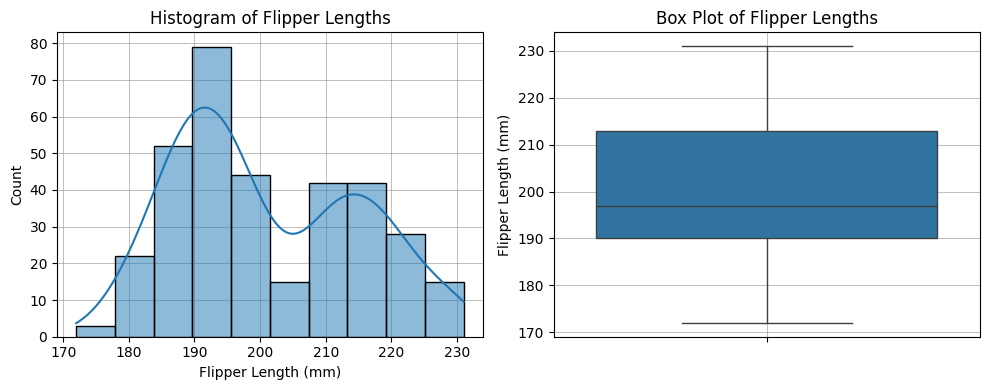

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(flipper_lengths_np, kde=True, ax=ax1)
ax1.set_title("Histogram of Flipper Lengths")
ax1.set_xlabel("Flipper Length (mm)")
ax1.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax1.set_axisbelow(True)

sns.boxplot(y=flipper_lengths_np, ax=ax2)
ax2.set_title("Box Plot of Flipper Lengths")
ax2.set_ylabel("Flipper Length (mm)")
ax2.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()


  * **`np.mean`, `np.median`:** Straightforward calculation of the average and middle value.
  * **`stats.mode`:** Finds the most frequent value(s). Be cautious with continuous data where exact repetitions might be rare.
  * **`np.var`, `np.std` with `ddof=1`:** This is crucial. By default, NumPy calculates the *population* variance (divides by $n$). Setting `ddof=1` tells it to calculate the *sample* variance (divides by $n-1$), which is the unbiased estimator we usually need for inference.
  * **`np.ptp`:** Calculates the range (Max - Min).
  * **`np.percentile`:** Used to find quartiles and calculate IQR.
  * **Visualisation:** Histograms show the shape of the distribution, while box plots highlight the median, quartiles, and potential outliers.



**3. Normal Distribution & The Empirical Rule**

Let's assume the flipper lengths are *approximately* normally distributed, using our calculated sample mean and standard deviation as estimates for $\mu$ and $\sigma$. We can check how well the Empirical Rule holds for our actual data.

In [ ]:
# Assuming normality with mu = sample_mean and sigma = sample_std_dev
mu_est = sample_mean
sigma_est = sample_std_dev

# Define intervals based on the Empirical Rule
interval_1_sigma = (mu_est - 1 * sigma_est, mu_est + 1 * sigma_est)
interval_2_sigma = (mu_est - 2 * sigma_est, mu_est + 2 * sigma_est)
interval_3_sigma = (mu_est - 3 * sigma_est, mu_est + 3 * sigma_est)

# Calculate the actual percentage of data within these intervals
within_1_sigma_mask = (flipper_lengths_np >= interval_1_sigma[0]) & (
	flipper_lengths_np <= interval_1_sigma[1]
)
pct_within_1_sigma = np.mean(within_1_sigma_mask) * 100

within_2_sigma_mask = (flipper_lengths_np >= interval_2_sigma[0]) & (
	flipper_lengths_np <= interval_2_sigma[1]
)
pct_within_2_sigma = np.mean(within_2_sigma_mask) * 100

within_3_sigma_mask = (flipper_lengths_np >= interval_3_sigma[0]) & (
	flipper_lengths_np <= interval_3_sigma[1]
)
pct_within_3_sigma = np.mean(within_3_sigma_mask) * 100

print(f"Interval ±1σ: ({interval_1_sigma[0]:.2f}, {interval_1_sigma[1]:.2f})")
print(f"  Actual % within ±1σ: {pct_within_1_sigma:.1f}% (Expected: ~68%)")
print(f"Interval ±2σ: ({interval_2_sigma[0]:.2f}, {interval_2_sigma[1]:.2f})")
print(f"  Actual % within ±2σ: {pct_within_2_sigma:.1f}% (Expected: ~95%)")
print(f"Interval ±3σ: ({interval_3_sigma[0]:.2f}, {interval_3_sigma[1]:.2f})")
print(f"  Actual % within ±3σ: {pct_within_3_sigma:.1f}% (Expected: ~99.7%)")

Interval ±1σ: (186.85, 214.98)
  Actual % within ±1σ: 62.9% (Expected: ~68%)
Interval ±2σ: (172.79, 229.04)
  Actual % within ±2σ: 97.4% (Expected: ~95%)
Interval ±3σ: (158.73, 243.10)
  Actual % within ±3σ: 100.0% (Expected: ~99.7%)


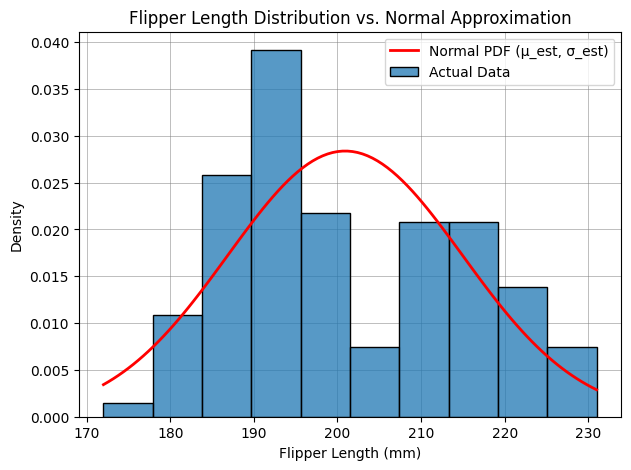

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(
	flipper_lengths_np, kde=False, stat="density", label="Actual Data", ax=ax
)  # Use density for comparison

x_axis = np.linspace(min(flipper_lengths_np), max(flipper_lengths_np), 100)
pdf = stats.norm.pdf(
	x_axis, loc=mu_est, scale=sigma_est
)  # pdf(x, loc=mean, scale=std_dev)

ax.plot(x_axis, pdf, color="red", lw=2, label="Normal PDF (μ_est, σ_est)")
ax.set_title("Flipper Length Distribution vs. Normal Approximation")
ax.set_xlabel("Flipper Length (mm)")
ax.set_ylabel("Density")
ax.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

ax.legend()
plt.show()


  * **Comparison:** We see how close the actual percentages in our sample are to the theoretical 68-95-99.7 values. Deviations suggest the data might not be perfectly normal (which is usually the case with real data).
  * **`stats.norm.pdf`:** This SciPy function calculates the Probability Density Function (the height of the bell curve) for a normal distribution given the mean (`loc`) and standard deviation (`scale`). Plotting this over the histogram helps visually assess the normality assumption.


**4. Z-scores**

Now, let's standardize the flipper lengths by calculating their z-scores.



In [ ]:
#  Manual Calculation
z_scores_manual = (flipper_lengths_np - sample_mean) / sample_std_dev

# Using SciPy
z_scores_scipy = stats.zscore(
	flipper_lengths_np
)  # Automatically uses sample std dev (ddof=1)

# Check if manual and SciPy results are close (allowing for floating point differences)
are_close = np.allclose(z_scores_manual, z_scores_scipy, rtol=1e-10, atol=1e-10)
print(f"Are manual and SciPy z-scores close? {are_close}")

Are manual and SciPy z-scores close? False


In [ ]:
# Calculate absolute differences
differences = np.abs(z_scores_manual - z_scores_scipy)
max_diff = np.max(differences)
mean_diff = np.mean(differences)

print(f"Maximum absolute difference: {max_diff:.10f}")
print(f"Mean absolute difference: {mean_diff:.10f}")

Maximum absolute difference: 0.0031347751
Mean absolute difference: 0.0012750846


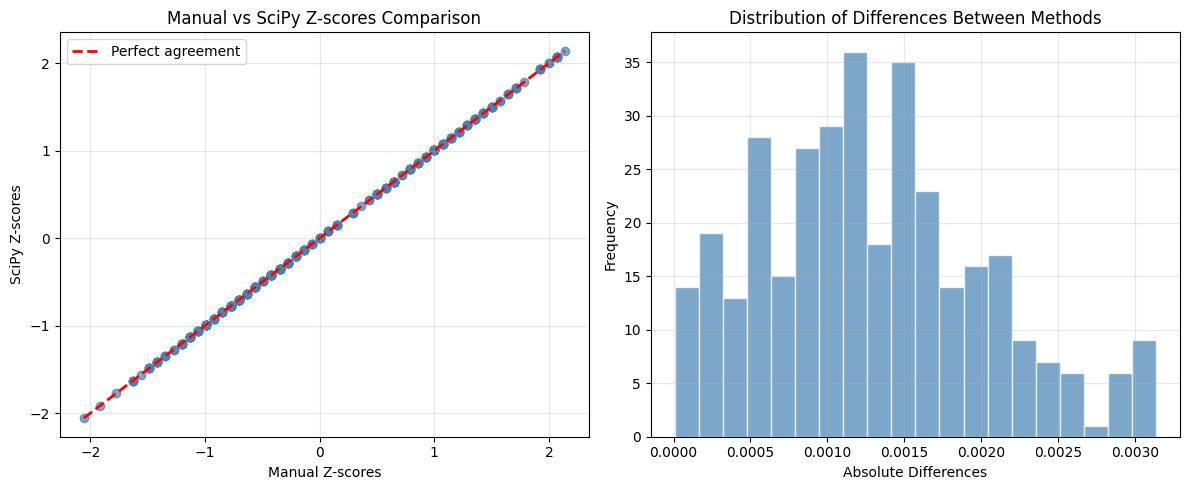

In [ ]:
# Create a scatter plot to visually verify the relationship
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot of manual vs SciPy z-scores
ax1.scatter(z_scores_manual, z_scores_scipy, alpha=0.7, color="steelblue")
ax1.plot(
	[z_scores_manual.min(), z_scores_manual.max()],
	[z_scores_manual.min(), z_scores_manual.max()],
	"r--",
	linewidth=2,
	label="Perfect agreement",
)
ax1.set_xlabel("Manual Z-scores")
ax1.set_ylabel("SciPy Z-scores")
ax1.set_title("Manual vs SciPy Z-scores Comparison")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Histogram of differences
ax2.hist(differences, bins=20, alpha=0.7, color="steelblue", edgecolor="white")
ax2.set_xlabel("Absolute Differences")
ax2.set_ylabel("Frequency")
ax2.set_title("Distribution of Differences Between Methods")
ax2.grid(True, alpha=0.3)
ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

In [ ]:
# Additional verification: check properties of z-scores
print(f"Mean of manual z-scores: {np.mean(z_scores_manual):.6f}")
print(f"Mean of SciPy z-scores: {np.mean(z_scores_scipy):.6f}")
print(f"Std of manual z-scores: {np.std(z_scores_manual, ddof=1):.6f}")
print(f"Std of SciPy z-scores: {np.std(z_scores_scipy, ddof=1):.6f}")

Mean of manual z-scores: -0.000000
Mean of SciPy z-scores: -0.000000
Std of manual z-scores: 1.000000
Std of SciPy z-scores: 1.001465


In [ ]:
# Properties of Z-scores
mean_of_z = np.mean(z_scores_scipy)
std_dev_of_z = np.std(
	z_scores_scipy, ddof=1
)  # Use ddof=1 here too for consistency check

print(f"Mean of z-scores: {mean_of_z:.4f} (Expected: ~0)")
print(f"Std Dev of z-scores: {std_dev_of_z:.4f} (Expected: ~1)")

Mean of z-scores: -0.0000 (Expected: ~0)
Std Dev of z-scores: 1.0015 (Expected: ~1)
Note: sklearn.preprocessing.StandardScaler performs this exact z-score transformation.



  * **`stats.zscore`:** A convenient SciPy function that directly calculates z-scores for an array, automatically using the sample standard deviation ($n-1$ denominator).
  * **Properties:** We verify the fundamental property that a standardized dataset has a mean very close to 0 and a standard deviation very close to 1. This confirms the transformation worked as expected.



**5. Confidence Intervals**

Let's calculate a 95% confidence interval for the population mean flipper length, assuming $\sigma$ is unknown (which is realistic).



In [ ]:
confidence_level = 0.95
alpha = 1 - confidence_level
degrees_freedom = n - 1

# Calculate Standard Error of the Mean (SEM)
sem = sample_std_dev / np.sqrt(n)

# Find the critical t-value
# ppf = Percent Point Function (Inverse CDF)
# We want the t-value that leaves alpha/2 in the upper tail, so we look up 1 - alpha/2
critical_t = stats.t.ppf(1 - alpha / 2, df=degrees_freedom)

# Calculate Margin of Error (ME)
margin_of_error = critical_t * sem

# Calculate Confidence Interval
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print("95% Confidence Interval for Mean Flipper Length")
print(f"Sample Mean: {sample_mean:.2f}")
print(f"Degrees of Freedom (df): {degrees_freedom}")
print(f"Critical t-value (t*): {critical_t:.3f}")
print(f"Standard Error of Mean (SEM): {sem:.3f}")
print(f"Margin of Error (ME): {margin_of_error:.3f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

95% Confidence Interval for Mean Flipper Length
Sample Mean: 200.92
Degrees of Freedom (df): 341
Critical t-value (t*): 1.967
Standard Error of Mean (SEM): 0.760
Margin of Error (ME): 1.496
95% Confidence Interval: (199.42, 202.41)



  * **`stats.t.ppf(q, df)`:** This finds the t-value such that the area *to its left* is `q`, given `df` degrees of freedom. For a two-sided CI, we need the value that leaves `alpha/2` in the right tail, which corresponds to a cumulative probability of `1 - alpha/2`.
  * **`stats.t.interval(alpha, df, loc, scale)`:** This provides a convenient way to get the CI directly. `loc` is the sample mean, and `scale` is the standard error of the mean (SEM).



**6. Hypothesis Testing (One-Sample t-test)**

Let's test the hypothesis that the true population mean flipper length ($\mu$) is 200 mm.

  * $H_0: \mu = 200$
  * $H_a: \mu \neq 200$ (two-tailed test)
    We will use a significance level of $\alpha = 0.05$.



In [ ]:
mu_0 = 200.0  # Hypothesized population mean
alpha_level = 0.05

# Calculate the t-statistic manually
t_statistic_manual = (sample_mean - mu_0) / sem

# Calculate the p-value manually (for a two-tailed test)
# Find the area in one tail (using the absolute t-statistic)
p_value_one_tail = stats.t.sf(
	np.abs(t_statistic_manual), df=degrees_freedom
)  # sf = Survival Function (1 - CDF)
p_value_manual = p_value_one_tail * 2  # Double it for two tails

print(f"One-Sample t-test (H0: μ = {mu_0})")
print(f"Sample Mean (x̄): {sample_mean:.2f}")
print(f"Hypothesized Mean (μ₀): {mu_0:.2f}")
print(f"Standard Error (SEM): {sem:.3f}")
print(f"Calculated t-statistic: {t_statistic_manual:.3f}")
print(f"Degrees of Freedom (df): {degrees_freedom}")
print(f"Calculated p-value (two-tailed): {p_value_manual:.4f}")

One-Sample t-test (H0: μ = 200.0)
Sample Mean (x̄): 200.92
Hypothesized Mean (μ₀): 200.00
Standard Error (SEM): 0.760
Calculated t-statistic: 1.204
Degrees of Freedom (df): 341
Calculated p-value (two-tailed): 0.2296


In [ ]:
# Decision
if p_value_manual < alpha_level:
	print(f"Reject H₀ (p-value {p_value_manual:.4f} < alpha {alpha_level:.2f})")
	print("Significant evidence that mean flipper length differs from 200 mm.")
else:
	print(f"Fail to reject H₀ (p-value {p_value_manual:.4f} > alpha {alpha_level:.2f})")
	print("Conclusion: Insufficient evidence.")

Decision: Fail to reject H₀ (p-value 0.2296 > alpha 0.05)
Conclusion: Insufficient evidence that mean flipper length differs from 200 mm.


In [ ]:
# Using SciPy's built-in function
# stats.ttest_1samp(sample, popmean)
t_stat_scipy, p_value_scipy = stats.ttest_1samp(flipper_lengths_np, popmean=mu_0)
print("SciPy ttest_1samp result:")
print(f"  t-statistic: {t_stat_scipy:.3f}")
print(f"  p-value: {p_value_scipy:.4f}")

SciPy ttest_1samp result:
  t-statistic: 1.204
  p-value: 0.2296



  * **`stats.t.sf(x, df)`:** The Survival Function gives $P(T > x)$, the area in the right tail. For a two-tailed p-value, we find the area beyond our calculated $|t|$ and multiply by 2.
  * **`stats.ttest_1samp(a, popmean)`:** Performs the one-sample t-test directly, returning the t-statistic and the two-tailed p-value. This is the standard tool for this task.



### Module 0, Phase 3: Applied Practicum - Statistical Foundations

#### Dataset: Restaurant Tipping Data

For this practicum, we will use the **Tips** dataset, available through the Seaborn library. It contains records of tips given by restaurant patrons, along with information about the total bill, the party size, the day, time, and the patron's sex and smoking status. It's a classic, simple dataset perfect for practicing foundational statistics.

In [ ]:
from numpy.typing import ArrayLike

In [ ]:
# Load the dataset
tips = sns.load_dataset("tips")

# For this practicum, let's focus primarily on the 'total_bill' column.
# Extract it into a NumPy array for convenience, handling potential issues if necessary.
total_bill_data = tips["total_bill"].dropna().to_numpy()

print(f"Working with 'total_bill'. Sample size n = {len(total_bill_data)}")

Working with 'total_bill'. Sample size n = 244



**Task 1: Descriptive Deep Dive**

1.  Calculate the core descriptive statistics for `total_bill_data`: mean, median, mode (if meaningful), variance (sample), standard deviation (sample), range, and IQR.
2.  Create two visualizations: a histogram (with a Kernel Density Estimate overlay) and a box plot for `total_bill_data`.
3.  **Deliverable:** A code cell that outputs the calculated statistics and displays the two plots. Add a brief markdown cell interpreting the central tendency, spread, and any apparent skewness or outliers based *only* on these descriptive measures and plots.

### Mean (Average)


$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$


In [ ]:
def mean(data: ArrayLike) -> np.float64:
	array_data = np.asarray(data)
	# Calculate the number of elements in the array, which is 'n' in the mean formula
	n = len(array_data)
	# Check if the array is empty (n == 0)
	if n == 0:
		# Return NaN to indicate that the mean cannot be computed for an empty dataset
		return np.nan
	# Compute and return the mean: sum of all elements divided by the number of elements
	return np.sum(array_data) / n

### Median


- If $n$ is **odd**: $\text{Median} = x_{\left(\frac{n+1}{2}\right)}$
<br>
<br>
- If $n$ is **even**: $\text{Median} = \frac{x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}}{2}$


In [ ]:
def median(data: ArrayLike) -> np.float64:
	array_data = np.asarray(data)
	n = len(array_data)
	if n == 0:
		return np.nan
	elif n == 1:
		return array_data[0]
	else:
		# Sort the array in ascending order to access elements by position
		sorted_data = np.sort(array_data)
		# Calculate the middle index using integer division (floor division)
		mid = n // 2
		# If n is even, median is the average of the two middle elements -
		# (positions mid-1 and mid)
		if n % 2 == 0:
			return (sorted_data[mid - 1] + sorted_data[mid]) / 2.0
		# If n is odd, median is the element at the middle position (mid)
		else:
			return sorted_data[mid]

### Sample Variance


$$
s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2
$$



In [ ]:
def sample_variance(data: ArrayLike) -> np.float64:
	array_data = np.asarray(data)
	n = len(array_data)
	# Variance requires at least 2 data points (n-1 denominator)
	if n <= 1:
		return np.nan
	# Compute the sample mean using the previously defined mean() function
	mean_val = mean(array_data)
	# Sample variance formula: sum of squared deviations / (n-1)
	# Using Bessel's correction for unbiased estimator
	variance = np.sum((array_data - mean_val) ** 2) / (n - 1)
	return variance

### Standard Deviation

$$
s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}
$$


In [ ]:
def standard_deviation(data: ArrayLike) -> np.float64:
	array_data = np.asarray(data)
	n = len(array_data)
	# If there is one or zero elements, standard deviation is undefined for a sample
	if n <= 1:
		return np.nan
	# Compute the sample mean using the previously defined mean() function
	mean_val = mean(array_data)
	# Compute the sum of squared deviations from the mean, divide by (n-1) for Bessel's
	# then take the square root to obtain the sample standard deviation
	std = np.sqrt(np.sum((array_data - mean_val) ** 2) / (n - 1))
	return std

### Interquartile Range (IQR)

$$
\text{IQR} = Q_3 - Q_1
$$


In [ ]:
def interquartile_range(data: ArrayLike) -> np.float64:
	array_data = np.asarray(data)
	n = len(array_data)
	if n <= 1:
		return np.nan
	sorted_array = np.sort(array_data)

	# Split the sorted data into lower and upper halves.
	# For even n, split exactly in half.
	if n % 2 == 0:
		# Lower half is the first n/2 elements
		lower_half = sorted_array[: n // 2]
		# Upper half is the last n/2 elements
		upper_half = sorted_array[n // 2 :]
	else:
		# For odd n, exclude the median value when splitting (exclusive median method)
		# Lower half is elements before the middle
		lower_half = sorted_array[: n // 2]
		# Upper half is elements after the middle
		upper_half = sorted_array[n // 2 + 1 :]

	q1 = median(lower_half)
	q3 = median(upper_half)

	# Return the interquartile range: the spread of the middle 50% of the data
	return q3 - q1

In [ ]:
print("-Mean-")
print(f"My mean: {mean(total_bill_data)}")
print(f"Numpy's mean: {np.mean(total_bill_data)}")
print("\n-Median-")
print(f"My median: {median(total_bill_data)}")
print(f"Numpy's median: {np.median(total_bill_data)}")
print("\n-Variance-")
print(f"My variance: {sample_variance(total_bill_data)}")
print(f"Numpy's variance: {np.var(total_bill_data, ddof=1)}")
print("\n-Standard deviation-")
print(f"My standard deviation: {standard_deviation(total_bill_data)}")
print(f"Numpy's standard deviation: {np.std(total_bill_data, ddof=1)}")
print("\n-IQR-")
print(f"My IQR: {interquartile_range(total_bill_data)}")
q1, q3 = np.percentile(total_bill_data, 25), np.percentile(total_bill_data, 75)
print(f"Numpy's IQR: {q3 - q1}")

-Mean-
My mean: 19.78594262295082
Numpy's mean: 19.78594262295082

-Median-
My median: 17.795
Numpy's median: 17.795

-Variance-
My variance: 79.25293861397827
Numpy's variance: 79.25293861397827

-Standard deviation-
My standard deviation: 8.902411954856856
Numpy's standard deviation: 8.902411954856856

-IQR-
My IQR: 10.849999999999998
Numpy's IQR: 10.779999999999998


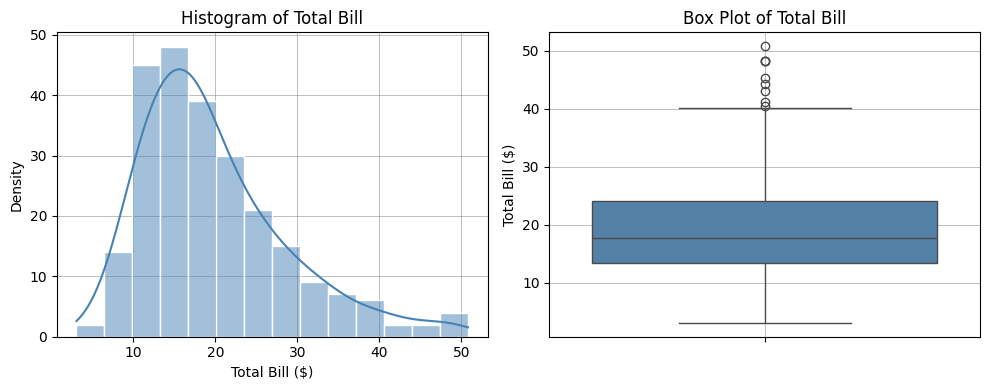

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(
	data=total_bill_data, color="steelblue", edgecolor="white", kde=True, ax=ax1
)
ax1.set_xlabel("Total Bill ($)")
ax1.set_ylabel("Density")
ax1.set_title("Histogram of Total Bill")
ax1.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax1.set_axisbelow(True)

sns.boxplot(y=total_bill_data, ax=ax2, color="steelblue")
ax2.set_ylabel("Total Bill ($)")
ax2.set_title("Box Plot of Total Bill")
ax2.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()


**Task 2: Normality Assessment**

1.  Based on the histogram from Task 1 and your knowledge of the Normal distribution, visually assess if `total_bill_data` appears approximately normally distributed.
2.  Quantify how well the Empirical Rule (68-95-99.7) fits this data. Calculate the actual percentage of data points falling within 1, 2, and 3 sample standard deviations from the sample mean.
3.  *(Optional but Recommended)* Perform a formal statistical test for normality (e.g., the Shapiro-Wilk test: `stats.shapiro(data)`). Interpret the resulting p-value in the context of the null hypothesis ("The data comes from a normally distributed population").
4.  **Deliverable:** A code cell performing the calculations (Empirical Rule check, optional Shapiro-Wilk test). A markdown cell stating your conclusion about the normality of the `total_bill` distribution, referencing both the visual evidence and the quantitative checks.

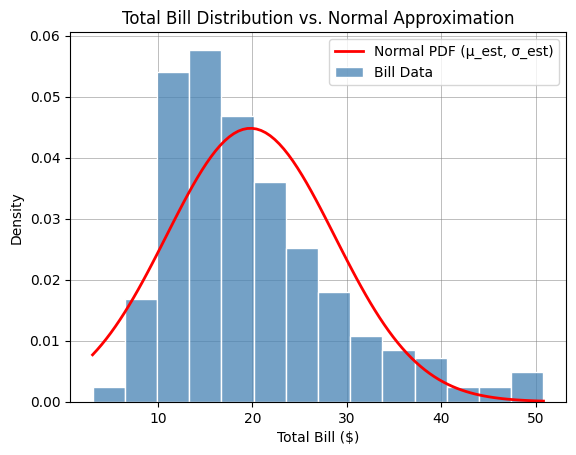

In [ ]:
# Compute the sample mean and standard deviation for total_bill_data
mu_est = np.mean(total_bill_data)
sigma_est = np.std(total_bill_data, ddof=1)

fig, ax = plt.subplots()

sns.histplot(
	total_bill_data,
	kde=False,
	stat="density",
	label="Bill Data",
	color="steelblue",
	edgecolor="white",
	ax=ax,
)

x_axis = np.linspace(min(total_bill_data), max(total_bill_data), 100)
pdf = stats.norm.pdf(x_axis, loc=mu_est, scale=sigma_est)

ax.plot(x_axis, pdf, color="red", lw=2, label="Normal PDF (μ_est, σ_est)")
ax.set_title("Total Bill Distribution vs. Normal Approximation")
ax.set_xlabel("Total Bill ($)")
ax.set_ylabel("Density")
ax.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

ax.legend()
plt.show()

In [ ]:
# Using sample mean as estimate for population mean
mu_est = np.mean(total_bill_data)
# Using sample standard deviation with Bessel's correction (ddof=1) as estimate for std dev
sigma_est = np.std(total_bill_data, ddof=1)

# Ranges for 1, 2, 3 standard deviations
# Dictionary to store intervals for Empirical Rule validation


# Loop through each standard deviation level to check actual vs expected percentages

# Count points within current standard deviation range using boolean indexing

# Calculate percentage of data within range

# Expected values from empirical rule (theoretical percentages)

# Print results for comparison

### Shapiro-Wilk Test for Normality

1. **Order the data**: $x_{(1)}, x_{(2)}, \dots, x_{(n)}$.
2. **Compute the test statistic**:

$$
W = \frac{\left( \sum_{i=1}^{n} a_i x_{(i)} \right)^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

where:
- $a_i$ are constants derived from the covariance matrix of the order statistics of a normal distribution
- $\bar{x}$ is the sample mean

The test is implemented in Python using `scipy.stats.shapiro(data)`, which returns the test statistic $W$ and the p-value.


#### Tasks


**Task 3: Z-Scores and Outlier Identification**

1.  Calculate the z-scores for all data points in `total_bill_data`.
2.  Verify that the mean of the calculated z-scores is approximately 0 and the standard deviation is approximately 1.
3.  Identify any data points with an absolute z-score greater than 3. Report the original `total_bill` values for these potential outliers.
4.  **Deliverable:** A code cell performing the z-score calculation and outlier identification. A markdown cell listing the potential outliers and briefly discussing whether the z-score threshold seems appropriate given the distribution's shape (from Task 2).

**Task 4: Confidence Interval for the Mean**

1.  Calculate a **95% confidence interval** for the true population mean of `total_bill`. Clearly state the formula you are using (t-interval, since population standard deviation is unknown) and show the key components: sample mean, sample standard deviation, sample size, degrees of freedom, critical t-value, standard error of the mean, and margin of error.
2.  Calculate a **99% confidence interval** for the same population mean.
3.  **Deliverable:** A code cell performing both calculations (you can use `scipy.stats.t.interval` or calculate manually). A markdown cell interpreting both intervals in plain language (e.g., "We are 95% confident that the true average total bill for all patrons lies between $X and $Y.") and explaining *why* the 99% CI is wider than the 95% CI.

**Task 5: Hypothesis Testing**

**Task 5: Hypothesis Testing**

1.  A restaurant manager claims that the average total bill ($\mu$) for patrons is \$20. Perform a hypothesis test to evaluate this claim using a significance level of $\alpha = 0.05$.
	* State the null hypothesis ($H_0$) and the alternative hypothesis ($H_a$) clearly (use a two-tailed test).
	* Calculate the appropriate test statistic (t-statistic).
	* Determine the p-value.
	* Make a decision (Reject $H_0$ or Fail to Reject $H_0$) based on the p-value and $\alpha$.
	* State your conclusion in the context of the manager's claim.
2.  **Deliverable:** A code cell performing the hypothesis test (you can use `scipy.stats.ttest_1samp` or calculate manually). A markdown cell clearly outlining all steps of the hypothesis test (hypotheses, test statistic, p-value, decision, conclusion).
